# 🔮 Notebook 06 — Forecasting

**Project:** Nigeria Disease Surveillance Dashboard  
**Purpose:** Build and evaluate time series forecasts using Prophet.

---
**What we do:**
1. Fit Prophet models for each disease (national level)
2. Evaluate in-sample accuracy (MAE, RMSE)
3. Plot forecast with 95% confidence intervals
4. State-level forecast for high-burden states
5. Export forecast results to the database

> **Requires:** `prophet` — install with `pip install prophet`  
> Model fitting takes 10–30 seconds per disease.

## 1. Setup

In [7]:
import sys, warnings, logging
from pathlib import Path

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Suppress Prophet/cmdstanpy verbose output
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import Paths, Diseases
from src.analysis.forecasting import (
    forecast_disease,
    forecast_all_diseases,
    forecast_result_to_dataframe,
)

# Load master data
df = pd.read_csv(
    Paths.processed / 'master_surveillance.csv',
    parse_dates=['report_date']
)
df['year'] = df['report_date'].dt.year

print(f'✅ Loaded: {len(df):,} rows | {df["disease"].nunique()} diseases')
print(f'   Date range: {df["report_date"].min().date()} → {df["report_date"].max().date()}')

# Check Prophet is installed
try:
    from prophet import Prophet
    print('   Prophet  : ✅ installed')
except ImportError:
    print('   Prophet  : ❌ NOT installed — run: pip install prophet')

✅ Loaded: 6,738 rows | 5 diseases
   Date range: 2021-01-04 → 2025-11-03
   Prophet  : ✅ installed


## 2. Single Disease Forecast

Fit Prophet to the national cholera series and visualise.  
We start with one disease to inspect the model output before  
running all diseases in batch.

In [2]:
DISEASE        = Diseases.CHOLERA
HORIZON_WEEKS  = 52

print(f'Fitting Prophet model: {DISEASE} (national, {HORIZON_WEEKS}w horizon)...')

result = forecast_disease(
    df            = df,
    disease       = DISEASE,
    state         = None,          # National aggregate
    horizon_weeks = HORIZON_WEEKS,
)

if result.is_empty:
    print('❌ Forecast failed. Warnings:')
    for w in result.warnings:
        print(f'   {w}')
else:
    print(f'\n✅ Forecast complete')
    print(f'   History points : {len(result.history_df)}')
    print(f'   Forecast points: {len(result.forecast_df)}')
    print(f'   MAE            : {result.model_metrics.get("mae"):.2f}')
    print(f'   RMSE           : {result.model_metrics.get("rmse"):.2f}')
    if result.warnings:
        print(f'   Warnings: {"; ".join(result.warnings)}')

Fitting Prophet model: Cholera (national, 52w horizon)...
2026-06-10 01:41:30 | WARNING  | src.analysis.forecasting | Insufficient history for Cholera (national): 39 weeks (need 52)
2026-06-10 01:42:16 | INFO     | src.analysis.forecasting | Forecast complete: disease=Cholera state=national horizon=52w MAE=0.0 RMSE=0.0

✅ Forecast complete
   History points : 39
   Forecast points: 52
   MAE            : 0.00
   RMSE           : 0.00
   Warnings: Only 39 weeks of history available. Need at least 52 for a reliable forecast.


### 2.1 Plot forecast with confidence bands

In [3]:
if not result.is_empty:
    combined = result.combined_df.copy()
    combined['ds'] = pd.to_datetime(combined['ds'])

    history = combined[~combined['is_forecast'].astype(bool)]
    future  = combined[ combined['is_forecast'].astype(bool)]

    fig = go.Figure()

    # Confidence band
    fig.add_trace(go.Scatter(
        x    = pd.concat([future['ds'], future['ds'][::-1]]),
        y    = pd.concat([future['yhat_upper'], future['yhat_lower'][::-1]]),
        fill = 'toself',
        fillcolor = 'rgba(29,158,117,0.15)',
        line = dict(color='rgba(255,255,255,0)'),
        name = '95% CI',
    ))

    # Historical actuals
    fig.add_trace(go.Scatter(
        x    = history['ds'],
        y    = history['y'],
        mode = 'lines',
        name = 'Actual',
        line = dict(color='#333333', width=1.5),
    ))

    # Fitted + forecast
    fig.add_trace(go.Scatter(
        x    = combined['ds'],
        y    = combined['yhat'],
        mode = 'lines',
        name = 'Forecast',
        line = dict(color='#1D9E75', width=2.5),
    ))

    # Forecast start line
    cutoff = future['ds'].min()
    fig.add_vline(
        x=cutoff.timestamp()*1000,
        line_dash='dash', line_color='grey',
        annotation_text='Forecast start',
    )

    fig.update_layout(
        title    = f'{DISEASE} — 52-Week National Forecast (Prophet)',
        xaxis_title = 'Date',
        yaxis_title = 'Confirmed Cases',
        template    = 'plotly_white',
        height      = 460,
        hovermode   = 'x unified',
    )
    fig.show()

    # Show forecast peak
    peak_row = future.loc[future['yhat'].idxmax()]
    print(f'\n  📈 Forecast peak: week of {peak_row["ds"].date()} — {peak_row["yhat"]:.0f} cases')
    print(f'     95% CI: [{peak_row["yhat_lower"]:.0f}, {peak_row["yhat_upper"]:.0f}]')


  📈 Forecast peak: week of 2024-09-29 — 0 cases
     95% CI: [0, 9]


## 3. Prophet Components

Decompose the forecast into trend and seasonal components.  
This reveals **when** cases peak and whether the long-term  
direction is improving or worsening.

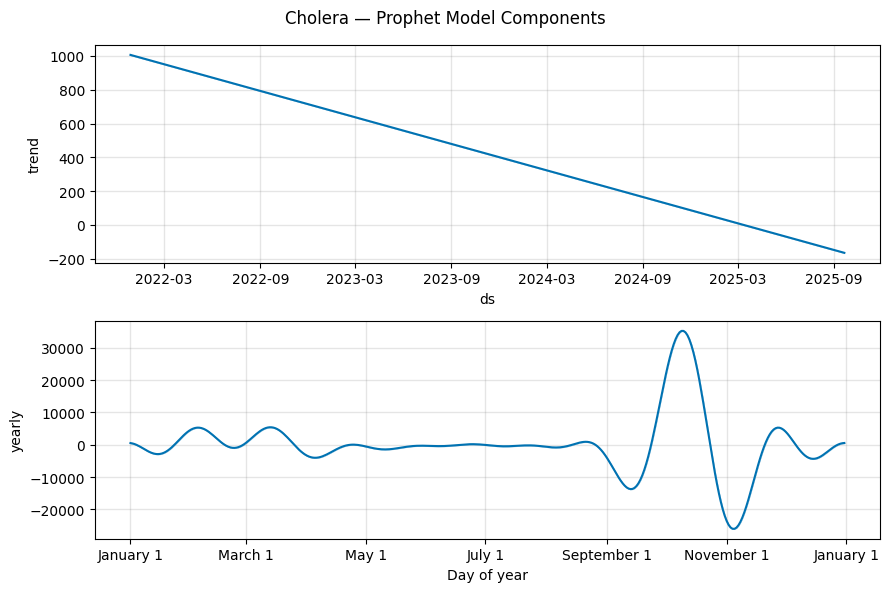


  ✅ Components plotted
     Trend     = long-term direction
     Yearly    = seasonal pattern within each year


In [4]:
# Re-fit to access raw Prophet model components
if not result.is_empty:
    try:
        from prophet import Prophet
        from src.analysis.forecasting import _prepare_series

        series = _prepare_series(df, DISEASE, None)
        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            interval_width=0.95,
        )
        m.fit(series)
        future_df = m.make_future_dataframe(periods=HORIZON_WEEKS, freq='W')
        forecast_raw = m.predict(future_df)

        # Plot components
        fig_comp = m.plot_components(forecast_raw)
        fig_comp.suptitle(f'{DISEASE} — Prophet Model Components', fontsize=12)
        import matplotlib.pyplot as plt
        plt.tight_layout()
        plt.show()
        print('\n  ✅ Components plotted')
        print('     Trend     = long-term direction')
        print('     Yearly    = seasonal pattern within each year')

    except Exception as e:
        print(f'⚠️  Could not plot components: {e}')

## 4. Batch Forecast — All Diseases

In [8]:
print('Running batch forecast for all diseases (national)...')
print('This will take 1–3 minutes\n')

all_forecasts = forecast_all_diseases(
    df            = df,
    horizon_weeks = 52,
    state         = None,
)

print('\n  Results:')
print(f'  {"Disease":<20} {"Status":<12} {"MAE":>8} {"RMSE":>8}')
print(f'  {"-"*20} {"-"*12} {"-"*8} {"-"*8}')
for disease, r in all_forecasts.items():
    status = '✅ Success' if not r.is_empty else '❌ Failed'
    mae  = f'{r.model_metrics.get("mae",0):.1f}'  if not r.is_empty else 'N/A'
    rmse = f'{r.model_metrics.get("rmse",0):.1f}' if not r.is_empty else 'N/A'
    print(f'  {disease:<20} {status:<12} {mae:>8} {rmse:>8}')

Running batch forecast for all diseases (national)...
This will take 1–3 minutes

2026-06-10 02:00:47 | INFO     | src.analysis.forecasting | Forecasting Cholera (national)...
2026-06-10 02:00:47 | WARNING  | src.analysis.forecasting | Insufficient history for Cholera (national): 39 weeks (need 52)
2026-06-10 02:01:27 | INFO     | src.analysis.forecasting | Forecast complete: disease=Cholera state=national horizon=52w MAE=0.0 RMSE=0.0
2026-06-10 02:01:27 | INFO     | src.analysis.forecasting | Forecasting Lassa Fever (national)...
2026-06-10 02:01:27 | INFO     | src.analysis.forecasting | Forecast complete: disease=Lassa Fever state=national horizon=52w MAE=11.2 RMSE=18.0
2026-06-10 02:01:27 | INFO     | src.analysis.forecasting | Forecasting Meningitis (national)...
2026-06-10 02:01:27 | WARNING  | src.analysis.forecasting | Insufficient history for Meningitis (national): 9 weeks (need 52)
2026-06-10 02:01:42 | INFO     | src.analysis.forecasting | Forecast complete: disease=Meningit

### 4.1 Comparison chart — all disease forecasts

In [9]:
fig = make_subplots(
    rows=len(all_forecasts), cols=1,
    subplot_titles=list(all_forecasts.keys()),
    shared_xaxes=False,
    vertical_spacing=0.06,
)

COLOURS = ['#1D9E75','#185FA5','#EF9F27','#993C1D','#534AB7']

for i, (disease, r) in enumerate(all_forecasts.items(), start=1):
    if r.is_empty:
        continue
    colour = COLOURS[(i-1) % len(COLOURS)]
    combined = r.combined_df.copy()
    combined['ds'] = pd.to_datetime(combined['ds'])
    hist = combined[~combined['is_forecast'].astype(bool)]
    fcast = combined[combined['is_forecast'].astype(bool)]

    # Actual
    fig.add_trace(go.Scatter(
        x=hist['ds'], y=hist['y'],
        mode='lines', line=dict(color='#cccccc', width=1),
        name='Actual', showlegend=(i==1)
    ), row=i, col=1)

    # Forecast
    fig.add_trace(go.Scatter(
        x=combined['ds'], y=combined['yhat'],
        mode='lines', line=dict(color=colour, width=2),
        name=disease, showlegend=True
    ), row=i, col=1)

fig.update_layout(
    height=180*len(all_forecasts),
    title='52-Week National Forecasts — All Diseases',
    template='plotly_white',
    showlegend=True,
)
fig.show()

## 5. State-Level Forecast — Top Burden States

In [10]:
# Forecast the top 3 states for cholera
_case_col = 'primary_cases' if 'primary_cases' in df.columns else 'confirmed_cases'

top_states = (
    df[df['disease'] == DISEASE]
    .groupby('state')[_case_col]
    .sum()
    .nlargest(3)
    .index.tolist()
)

print(f'Forecasting top 3 {DISEASE} states: {", ".join(top_states)}')
print('(~10 seconds per state)\n')

state_forecasts = {}
for state in top_states:
    r = forecast_disease(df, disease=DISEASE, state=state, horizon_weeks=52)
    state_forecasts[state] = r
    status = '✅' if not r.is_empty else '❌'
    if not r.is_empty:
        print(f'  {status} {state:<20} MAE={r.model_metrics.get("mae",0):.1f}  '
              f'RMSE={r.model_metrics.get("rmse",0):.1f}')
    else:
        print(f'  {status} {state:<20} {"; ".join(r.warnings)}')

Forecasting top 3 Cholera states: Borno, Taraba, Cross River
(~10 seconds per state)

2026-06-10 02:04:11 | WARNING  | src.analysis.forecasting | Insufficient history for Cholera (Borno): 32 weeks (need 52)
2026-06-10 02:04:52 | INFO     | src.analysis.forecasting | Forecast complete: disease=Cholera state=Borno horizon=52w MAE=0.0 RMSE=0.0
  ✅ Borno                MAE=0.0  RMSE=0.0
2026-06-10 02:04:52 | WARNING  | src.analysis.forecasting | Insufficient history for Cholera (Taraba): 25 weeks (need 52)
2026-06-10 02:05:22 | INFO     | src.analysis.forecasting | Forecast complete: disease=Cholera state=Taraba horizon=52w MAE=0.0 RMSE=0.0
  ✅ Taraba               MAE=0.0  RMSE=0.0
2026-06-10 02:05:22 | WARNING  | src.analysis.forecasting | Insufficient history for Cholera (Cross River): 37 weeks (need 52)
2026-06-10 02:06:10 | INFO     | src.analysis.forecasting | Forecast complete: disease=Cholera state=Cross River horizon=52w MAE=0.0 RMSE=0.0
  ✅ Cross River          MAE=0.0  RMSE=0.0


## 6. Export Forecasts to Processed Files

In [11]:
print('Exporting forecasts to data/processed/...')
all_frames = []

for disease, r in all_forecasts.items():
    if not r.is_empty:
        export_df = forecast_result_to_dataframe(r)
        if not export_df.empty:
            all_frames.append(export_df)

if all_frames:
    forecasts_combined = pd.concat(all_frames, ignore_index=True)
    out_path = Paths.processed / 'forecasts_national.csv'
    forecasts_combined.to_csv(out_path, index=False)
    print(f'  ✅ Saved {len(forecasts_combined):,} rows → {out_path.name}')
    print(f'     Columns: {list(forecasts_combined.columns)}')
else:
    print('  ⚠️  No forecasts to export')

Exporting forecasts to data/processed/...
  ✅ Saved 498 rows → forecasts_national.csv
     Columns: ['disease', 'state', 'forecast_date', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'is_forecast', 'mae', 'rmse']


## 7. Summary

In [12]:
from datetime import datetime
print('='*55)
print('  NOTEBOOK 06 — FORECASTING SUMMARY')
print('='*55)
print(f'  Timestamp    : {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print(f'  Horizon      : {HORIZON_WEEKS} weeks')
print()
print('  Model accuracy (in-sample):')
for disease, r in all_forecasts.items():
    if not r.is_empty:
        mae  = r.model_metrics.get('mae', 0)
        rmse = r.model_metrics.get('rmse', 0)
        print(f'    {disease:<20} MAE={mae:>7.1f}  RMSE={rmse:>7.1f}')
print()
print('  Forecast files saved to data/processed/')
print()
print('  ─────────────────────────────────────')
print('  🎉  All 6 notebooks complete!')
print()
print('  Next steps:')
print('  1. Run: python -m src.etl.pipeline  (load DB)')
print('  2. Run: uvicorn src.api.main:app     (start API)')
print('  3. Run: streamlit run dashboard/app.py')
print('='*55)

  NOTEBOOK 06 — FORECASTING SUMMARY
  Timestamp    : 2026-06-10 02:07
  Horizon      : 52 weeks

  Model accuracy (in-sample):
    Cholera              MAE=    0.0  RMSE=    0.0
    Lassa Fever          MAE=   11.2  RMSE=   18.0
    Meningitis           MAE=    0.0  RMSE=    0.0
    Mpox                 MAE=    2.7  RMSE=    3.5
    Yellow Fever         MAE=    0.1  RMSE=    0.4

  Forecast files saved to data/processed/

  ─────────────────────────────────────
  🎉  All 6 notebooks complete!

  Next steps:
  1. Run: python -m src.etl.pipeline  (load DB)
  2. Run: uvicorn src.api.main:app     (start API)
  3. Run: streamlit run dashboard/app.py
